In [1]:
import pandas as pd
df=pd.read_csv("heart_disease_uci.csv")
df.head(10)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [2]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [18]:
#filling & dropping

num_cols=df.select_dtypes(include=['int64','float64']).columns
cat_cols=df.select_dtypes(include=['object']).columns

for c in num_cols:
    df[c].fillna(df[c].mean(), inplace=True)

for c in cat_cols:
    df[c].fillna(df[c].mode()[0], inplace=True)

for c in ['id','dataset']:
    if c in df.columns:
        df.drop(c,axis=1,inplace=True)

if 'num' in df.columns:
    df['num']=df['num'].apply(lambda x:0 if x==0 else 1)
    target='num'
else:
    target=df.columns[-1]

num_cols=df.select_dtypes(include=['int64','float64']).columns
cat_cols=df.select_dtypes(include=['object']).columns

df.to_csv("cleaned_heart_disease_uci.csv",index=False)

C:\Users\anjan\AppData\Local\Temp\ipykernel_16300\808733454.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[c].fillna(df[c].mean(), inplace=True)


In [6]:
#stats basic

stats=df[num_cols].describe().T
stats['variance']=df[num_cols].var()
stats['skewness']=df[num_cols].skew()
stats

,count,mean,std,min,25%,50%,75%,max,variance,skewness
age,920.0,53.510870,9.424685,28.0,47.000000,54.000000,60.000000,77.0,88.824691,-0.195994
trestbps,920.0,132.132404,18.443895,0.0,120.000000,130.000000,140.000000,200.0,340.177264,0.220498
chol,920.0,199.130337,108.957634,0.0,177.750000,221.000000,267.000000,603.0,11871.765920,-0.624062
thalch,920.0,137.545665,25.138494,60.0,120.000000,138.000000,156.000000,202.0,631.943902,-0.217704
oldpeak,920.0,0.878788,1.053774,-2.6,0.000000,0.800000,1.500000,6.2,1.110440,1.078270
ca,920.0,0.676375,0.541667,0.0,0.676375,0.676375,0.676375,3.0,0.293403,2.005385
num,920.0,0.995652,1.142693,0.0,0.000000,1.000000,2.000000,4.0,1.305748,0.968880


In [19]:
df[target].value_counts()

num
1    509
0    411
Name: count, dtype: int64

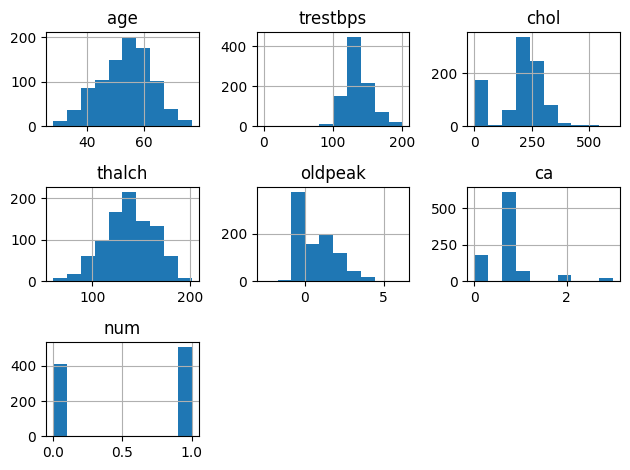

In [20]:
#visualization - histogram for all num cols

import matplotlib.pyplot as plt
df[num_cols].hist()
plt.tight_layout()
plt.show()

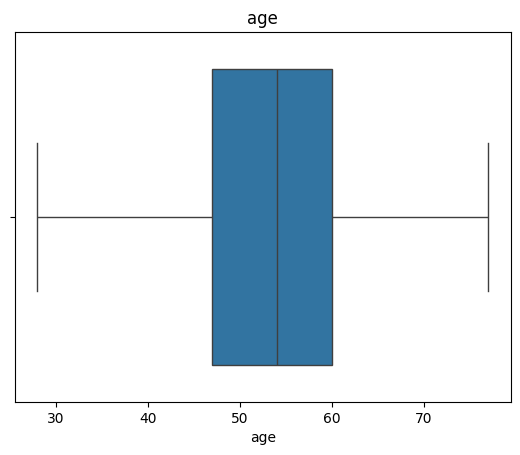

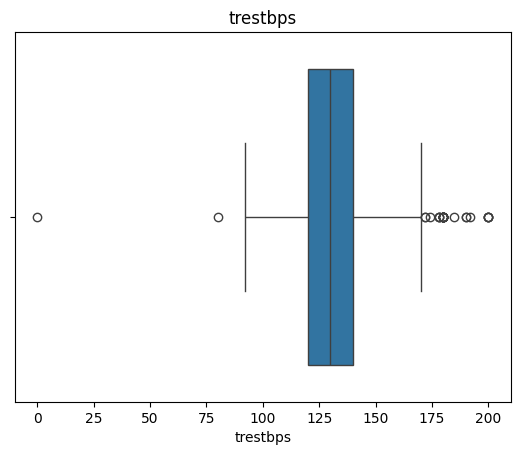

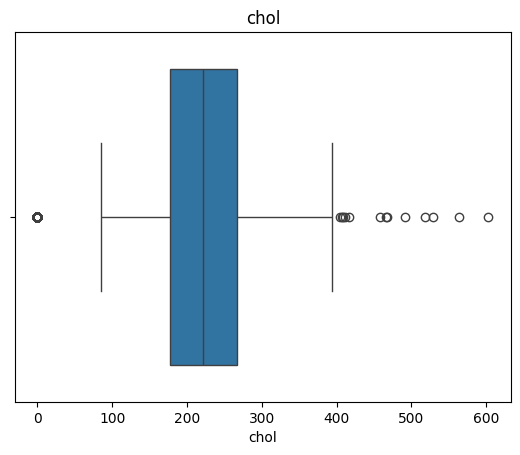

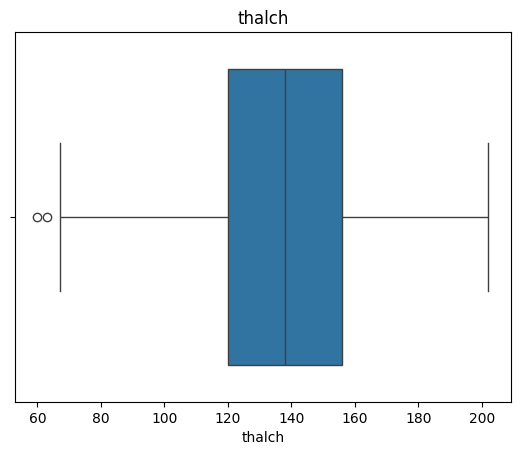

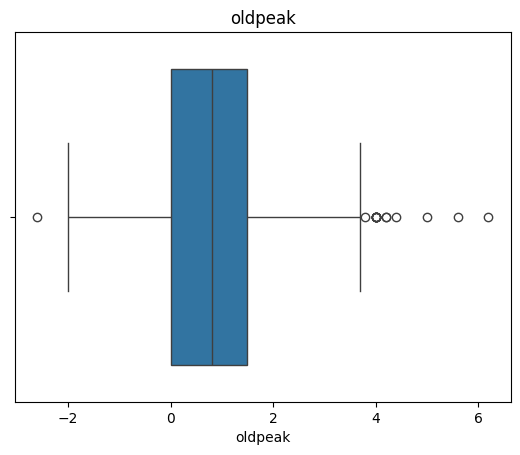

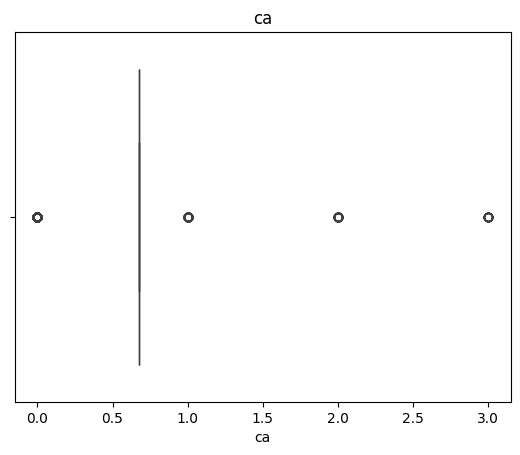

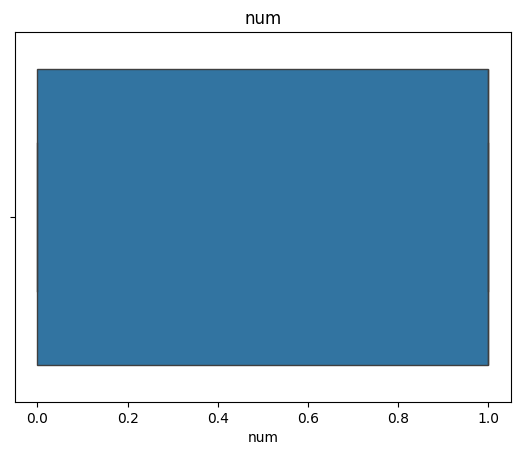

In [21]:
#boxplot 

import seaborn as sns
for c in num_cols:
    sns.boxplot(x=df[c])
    plt.title(c)
    plt.show()

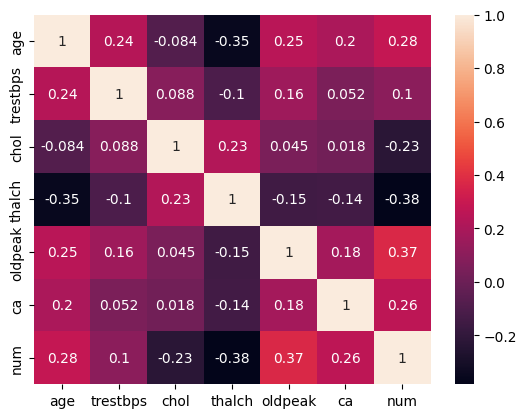

In [22]:
#corr

import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df[num_cols].corr(), annot=True)
plt.show()

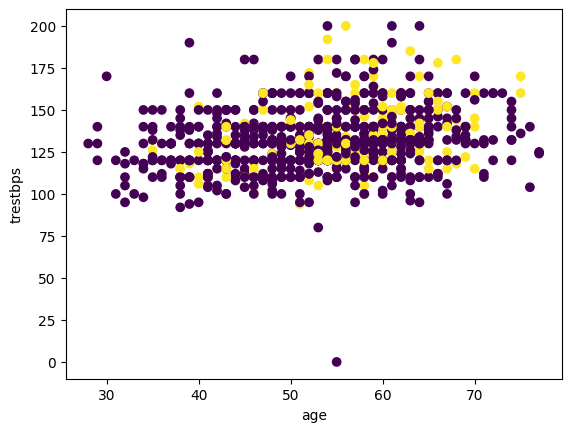

In [23]:
#scatter plot

target=df.columns[-1]
import matplotlib.pyplot as plt
plt.scatter(df[num_cols[0]], df[num_cols[1]], c=df[target])
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.show()

In [24]:
#encoding

df=pd.get_dummies(df, drop_first=True)
df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0.0,0,True,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,False,108.0,True,1.5,3.0,1,True,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,False,129.0,True,2.6,2.0,1,True,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,False,187.0,False,3.5,0.0,0,True,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0.0,0,False,True,False,False,False,False,False,True,True,False


In [25]:
#feature selection

import pandas as pd
corr=df.corr()[target].abs().sort_values(ascending=False)
top=corr[1:12].index
X=df[top]
y=df[target]

In [26]:
#train test split

from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
#scaling

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [28]:
#models

from sklearn.linear_model import LogisticRegression #logreg
from sklearn.tree import DecisionTreeClassifier #dt
from sklearn.ensemble import RandomForestClassifier #rf
from sklearn.svm import SVC
# from sklearn.naive_bayes import MultinomialNB #nb

models={
    "log":LogisticRegression(max_iter=1000),
    "dt":DecisionTreeClassifier(),
    "rf":RandomForestClassifier(n_estimators=200, max_depth=10,random_state=42),
    "svm":SVC(C=4.2,kernel='rbf')
    # "nb":MultinomialNB()
}

results={}

for name,model in models.items():
    model.fit(X_train,y_train)
    acc=model.score(X_test,y_test)
    results[name]=acc
    print(name,":",acc)

log : 0.9456521739130435
dt : 0.907608695652174
rf : 0.9402173913043478
svm : 0.9293478260869565


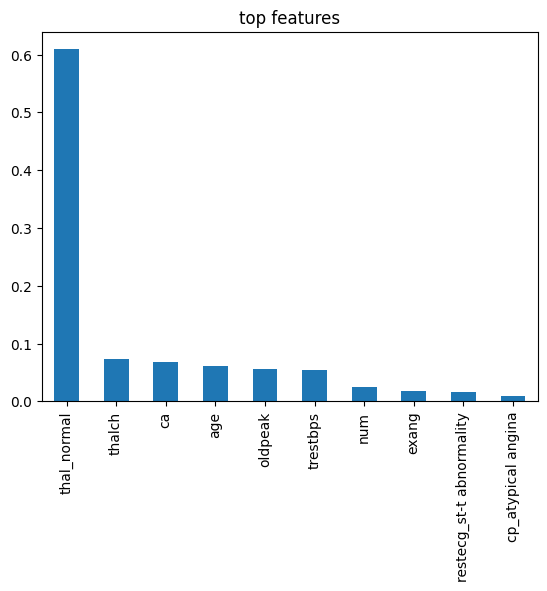

In [29]:
#rf feature imp

import pandas as pd
model=models["rf"]
imp=model.feature_importances_
feat_imp=pd.Series(imp,index=X.columns)
feat_imp.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("top features")
plt.show()

In [31]:
from sklearn.metrics import accuracy_score, classification_report
results={}
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    acc=accuracy_score(y_test, y_pred)
    results[name]=acc
    print("---",name,"---")
    print("acc:",acc)
    print(classification_report(y_test,y_pred))

--- log ---
acc: 0.9456521739130435
              precision    recall  f1-score   support

       False       0.99      0.93      0.96       138
        True       0.83      0.98      0.90        46

    accuracy                           0.95       184
   macro avg       0.91      0.96      0.93       184
weighted avg       0.95      0.95      0.95       184

--- dt ---
acc: 0.907608695652174
              precision    recall  f1-score   support

       False       0.94      0.93      0.94       138
        True       0.81      0.83      0.82        46

    accuracy                           0.91       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.91      0.91      0.91       184

--- rf ---
acc: 0.9402173913043478
              precision    recall  f1-score   support

       False       0.98      0.93      0.96       138
        True       0.83      0.96      0.89        46

    accuracy                           0.94       184
   macro avg       0.91

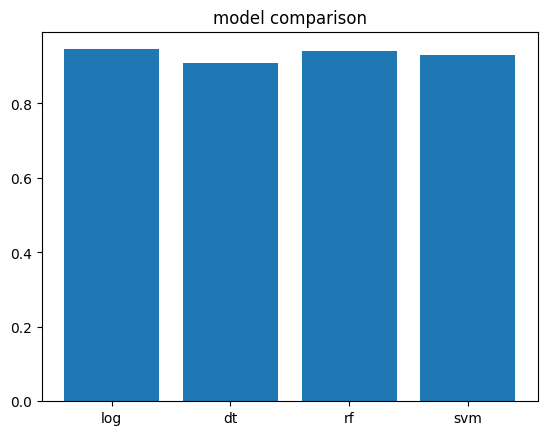

In [32]:
import matplotlib.pyplot as plt
plt.bar(results.keys(),results.values())
plt.title("model comparison")
plt.show()